In [1]:
# 05_quantum_machine_learning.py
"""
FlagQuantum Tutorial - Lesson 5: Quantum Machine Learning Basics
Goal: Master how to use quantum circuits for machine learning tasks
"""
import flagquantum as fq


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn


def make_moons_pytorch(n_samples=300, noise=0.1):
    """Generate moon-shaped dataset using PyTorch"""
    torch.manual_seed(42)

    n_samples_out = n_samples // 2
    n_samples_in = n_samples - n_samples_out

    # Generate outer arc (class 0)
    outer_circ_x = torch.cos(torch.linspace(0, math.pi, n_samples_out))
    outer_circ_y = torch.sin(torch.linspace(0, math.pi, n_samples_out))
    outer_circ_x = outer_circ_x + torch.randn(n_samples_out) * noise
    outer_circ_y = outer_circ_y + torch.randn(n_samples_out) * noise

    # Generate inner arc (class 1)
    inner_circ_x = 1 - torch.cos(torch.linspace(0, math.pi, n_samples_in))
    inner_circ_y = 0.5 - torch.sin(torch.linspace(0, math.pi, n_samples_in))
    inner_circ_x = inner_circ_x + torch.randn(n_samples_in) * noise
    inner_circ_y = inner_circ_y + torch.randn(n_samples_in) * noise

    x = torch.cat([
        torch.stack([outer_circ_x, outer_circ_y], dim=1),
        torch.stack([inner_circ_x, inner_circ_y], dim=1)
    ], dim=0)

    y = torch.cat([
        torch.zeros(n_samples_out, 1),
        torch.ones(n_samples_in, 1)
    ], dim=0)

    # Standardization
    mean = x.mean(dim=0)
    std = x.std(dim=0) + 1e-8
    x = (x - mean) / std

    return x, y


def train_test_split_pytorch(x, y, test_size=0.2, random_state=42):
    """PyTorch version of dataset splitting"""
    torch.manual_seed(random_state)

    n_samples = len(x)
    n_test = int(n_samples * test_size)

    indices = torch.randperm(n_samples)
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]

    x_train = x[train_indices]
    y_train = y[train_indices]
    x_test = x[test_indices]
    y_test = y[test_indices]

    return x_train, x_test, y_train, y_test


class SimpleQNN(nn.Module):
    """Simplified QNN (fixed batch size issue)"""

    def __init__(self, n_qubits=4, n_layers=2, invertible=True, device="cpu"):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.invertible = invertible
        self.device = device

        # Input projection (map features to qubits)
        self.input_proj = nn.Linear(2, n_qubits)

        # Build circuit
        self._build_circuit()

        # Output projection
        self.output_proj = nn.Linear(n_qubits, 1)

    def _build_circuit(self):
        """Build the circuit structure"""

        # Encoder
        func_list = [
            {"func": "ry", "wires": [i], "input_idx": [i]}
            for i in range(self.n_qubits)
        ]
        self.encoder = fq.GeneralEncoder(func_list)

        # Variational circuit
        base_mod = [self.encoder]

        for _ in range(self.n_layers):
            # CNOT entanglement chain (ring topology)
            for i in range(self.n_qubits):
                base_mod.append(fq.CX(wires=[i, (i + 1) % self.n_qubits]))

            # Trainable RY gates
            for i in range(self.n_qubits):
                base_mod.append(fq.RY(wires=[i], trainable=True))

        # Trainable U3 gates
        for i in range(self.n_qubits):
            base_mod.append(fq.U3(wires=[i], trainable=True))

        if self.invertible:
            self.circuit = fq.InvertibleUnitary(base_mod)
        else:
            self.circuit = None
            self.gates = nn.ModuleList(base_mod)

    def forward(self, x):
        """Forward pass"""
        batch_size = x.shape[0]

        # Project to qubit dimension
        x_qubit = self.input_proj(x)  # [batch, n_qubits]

        # Create device
        qdev = fq.DistributedQuantumDevice(
            n_wires=self.n_qubits,
            bsz=batch_size,
            device=self.device,
            invertible=self.invertible,
        )

        # Apply quantum circuit
        if self.invertible:
            self.circuit(qdev, x_qubit)
        else:
            self.encoder(qdev, x_qubit)
            for gate in self.gates[1:]:
                gate(qdev)

        # Measurement
        measurements = fq.measure_allZ(qdev, shots=0, training=True)

        # Output
        output = self.output_proj(measurements)

        return torch.sigmoid(output)


def train_qnn_classifier():
    """Train QNN binary classifier"""
    print("=" * 60)
    print("Quantum Neural Network - Binary Classification")
    print("=" * 60)
    n_epochs = 100
    batch_size = 32
    # 1. Create dataset
    print("\n1. Creating dataset...")
    x, y = make_moons_pytorch(n_samples=320, noise=0.1)

    # Split into training and test sets
    x_train, x_test, y_train, y_test = train_test_split_pytorch(
        x, y, test_size=0.2, random_state=42
    )

    # Adjust training samples to be a multiple of batch_size
    n_train = (len(x_train) // batch_size) * batch_size
    x_train = x_train[:n_train]
    y_train = y_train[:n_train]

    print(f"   Training samples: {len(x_train)}")
    print(f"   Test samples: {len(x_test)}")
    print(f"   Features: {x.shape[1]}")

    # 2. Create model
    print("\n2. Creating QNN model...")
    model = SimpleQNN(
        n_qubits=8,
        n_layers=8,
        invertible=True,
        device="cpu"
    )

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"   Total trainable parameters: {total_params}")

    # 3. Training setup
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()

    # 4. Training loop
    print("\n3. Training...")
    print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Test Loss':<12} {'Test Acc':<12}")
    print("-" * 65)



    best_test_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(n_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0

        # Random shuffle
        perm = torch.randperm(len(x_train))

        for i in range(0, len(x_train), batch_size):
            idx = perm[i:i+batch_size]
            batch_x = x_train[idx]
            batch_y = y_train[idx]

            # Ensure current batch size is consistent (last batch may be smaller)
            # But that's fine because qdev is recreated each forward pass
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(batch_x)
            pred = (output > 0.5).float()
            train_correct += (pred == batch_y).sum().item()

        train_loss /= len(x_train)
        train_acc = train_correct / len(x_train)

        # Testing
        model.eval()
        test_loss = 0.0
        test_correct = 0

        with torch.no_grad():
            for i in range(0, len(x_test), batch_size):
                batch_x = x_test[i:i+batch_size]
                batch_y = y_test[i:i+batch_size]

                output = model(batch_x)
                loss = criterion(output, batch_y)

                test_loss += loss.item() * len(batch_x)
                pred = (output > 0.5).float()
                test_correct += (pred == batch_y).sum().item()

        test_loss /= len(x_test)
        test_acc = test_correct / len(x_test)

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        # Save best model
        if test_acc > best_test_acc:
            best_test_acc = test_acc

        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"{epoch+1:<8} {train_loss:<12.4f} {train_acc:<12.4f} {test_loss:<12.4f} {test_acc:<12.4f}")

    print(f"\nBest test accuracy: {best_test_acc:.4f}")

    return model, history


def visualize_results(model, x, y, history):
    """Visualize training results"""
    print("\n4. Visualizing results...")

    # 1. Decision boundary
    print("   Plotting decision boundary...")
    x_min, x_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
    y_min, y_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 80),
                        np.linspace(y_min, y_max, 80))

    # Predict grid points (process in batches to avoid batch size mismatch)
    grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    model.eval()
    z_measurements = []
    batch_size = 32  # Use training batch size

    with torch.no_grad():
        for i in range(0, len(grid_points), batch_size):
            batch = grid_points[i:i+batch_size]
            z_batch = model(batch)
            z_measurements.append(z_batch)

    z_measurements = torch.cat(z_measurements, dim=0).numpy().reshape(xx.shape)

    plt.figure(figsize=(14, 5))

    # Subplot 1: Decision boundary
    plt.subplot(1, 3, 1)
    plt.contourf(xx, yy, z_measurements, levels=[0, 0.5, 1], alpha=0.3, colors=['blue', 'red'])
    plt.contour(xx, yy, z_measurements, levels=[0.5], colors='black', linewidths=2)

    # Data points
    plt.scatter(x[y.squeeze() == 0, 0], x[y.squeeze() == 0, 1],
                c='blue', label='Class 0', alpha=0.7, edgecolors='k', s=30)
    plt.scatter(x[y.squeeze() == 1, 0], x[y.squeeze() == 1, 1],
                c='red', label='Class 1', alpha=0.7, edgecolors='k', s=30)

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Quantum Neural Network Decision Boundary')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subplot 2: Loss curves
    plt.subplot(1, 3, 2)
    epochs = range(1, len(history['train_loss']) + 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    plt.plot(epochs, history['test_loss'], 'r-', label='Test Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Convergence')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subplot 3: Accuracy curves
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
    plt.plot(epochs, history['test_acc'], 'r-', label='Test Accuracy', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Convergence')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.savefig('qnn_results.png', dpi=150)
    plt.show()
    # print("   Results saved to 'qnn_results.png'")

Quantum Neural Network - Binary Classification

1. Creating dataset...
   Training samples: 256
   Test samples: 64
   Features: 2

2. Creating QNN model...
   Total trainable parameters: 33

3. Training...
Epoch    Train Loss   Train Acc    Test Loss    Test Acc    
-----------------------------------------------------------------
1        0.6883       0.5312       0.6799       0.5156      
5        0.6140       0.8203       0.6057       0.8281      
10       0.4601       0.8672       0.4365       0.8594      
15       0.3514       0.8516       0.3234       0.8594      
20       0.3140       0.8516       0.2906       0.8438      
25       0.3012       0.8750       0.2770       0.8438      
30       0.2866       0.8633       0.2707       0.8594      
35       0.2848       0.8672       0.2626       0.8594      
40       0.2739       0.8867       0.2500       0.8750      
45       0.2871       0.8789       0.2410       0.8750      
50       0.2620       0.8789       0.2264       0.8906  

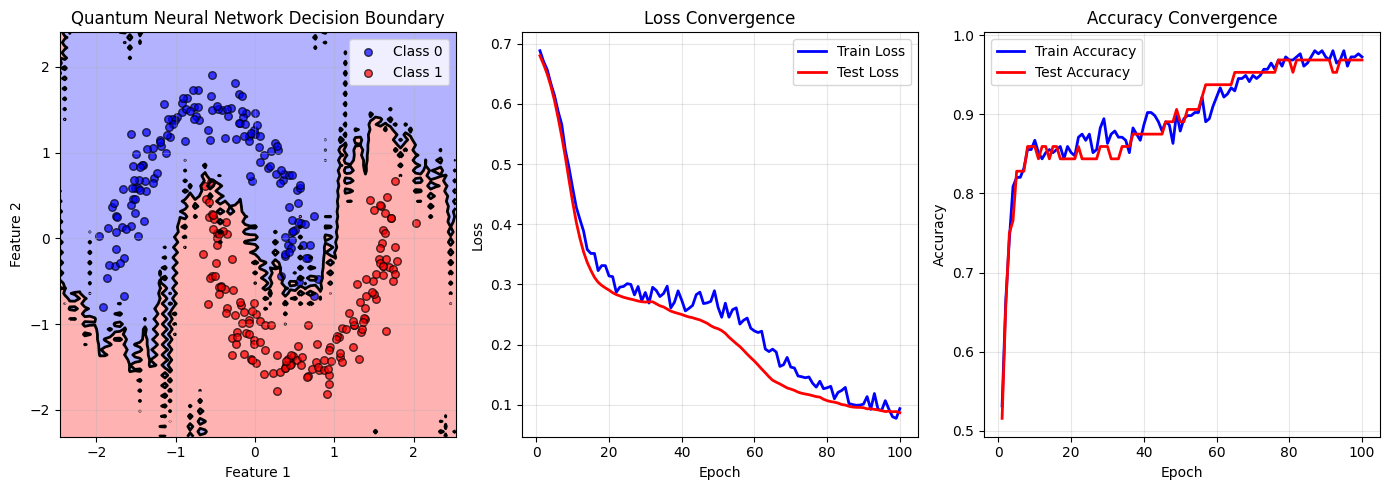


Summary
✅ Quantum Neural Network classifier has been trained successfully!
✅ The model uses invertible=True mode for gradient computation.


In [3]:
# 1. Train QNN classifier
model, history = train_qnn_classifier()

# 2. Visualize results
x, y = make_moons_pytorch(n_samples=300, noise=0.1)
visualize_results(model, x, y, history)

print("\n" + "=" * 60)
print("Summary")
print("=" * 60)
print("✅ Quantum Neural Network classifier has been trained successfully!")
print("✅ The model uses invertible=True mode for gradient computation.")